Plot successfully generated and saved as 'span_boundary_comparison.png'


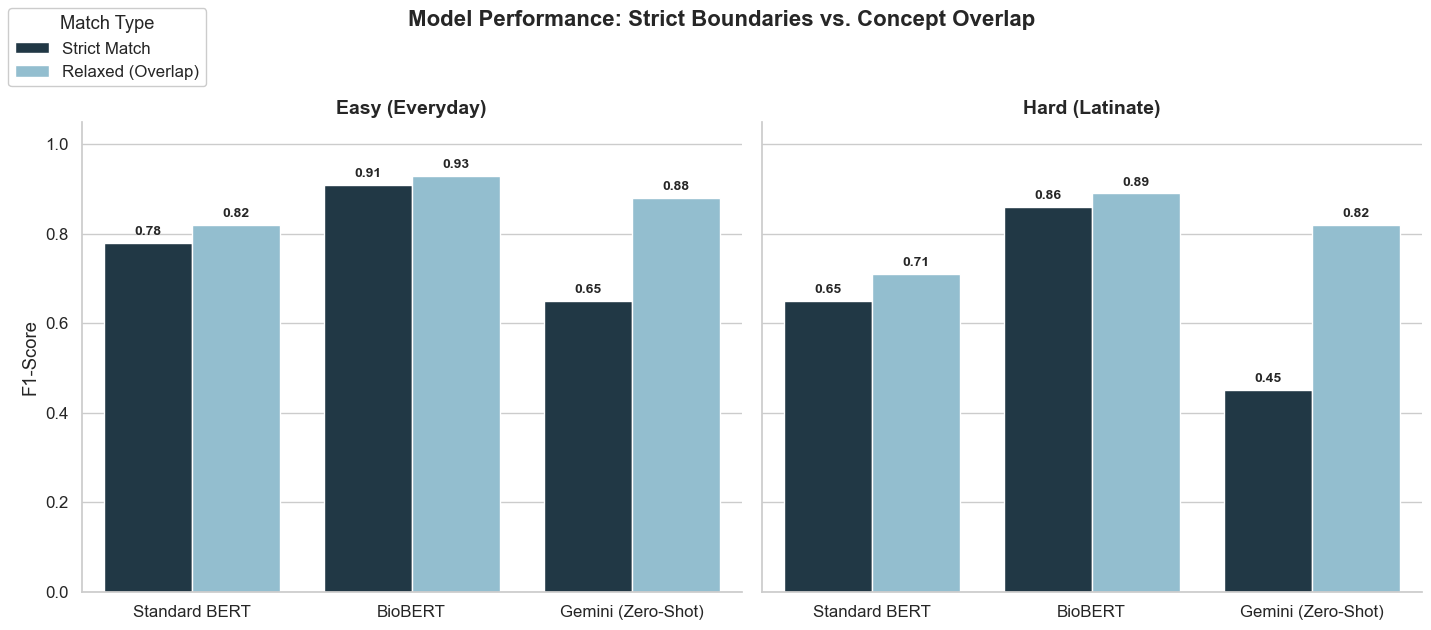

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def generate_span_boundary_plot():
    # 1. Input your data here!
    # Replace the 'F1_Score' numbers with the outputs from your calculate_dual_metrics script.
    data = [
        # --- EASY SUBSET ---
        {"Subset": "Easy (Everyday)", "Model": "Standard BERT", "Match Type": "Strict Match", "F1_Score": 0.78},
        {"Subset": "Easy (Everyday)", "Model": "Standard BERT", "Match Type": "Relaxed (Overlap)", "F1_Score": 0.82},
        
        {"Subset": "Easy (Everyday)", "Model": "BioBERT", "Match Type": "Strict Match", "F1_Score": 0.91},
        {"Subset": "Easy (Everyday)", "Model": "BioBERT", "Match Type": "Relaxed (Overlap)", "F1_Score": 0.93},
        
        {"Subset": "Easy (Everyday)", "Model": "Gemini (Zero-Shot)", "Match Type": "Strict Match", "F1_Score": 0.65},
        {"Subset": "Easy (Everyday)", "Model": "Gemini (Zero-Shot)", "Match Type": "Relaxed (Overlap)", "F1_Score": 0.88},

        # --- HARD SUBSET ---
        {"Subset": "Hard (Latinate)", "Model": "Standard BERT", "Match Type": "Strict Match", "F1_Score": 0.65},
        {"Subset": "Hard (Latinate)", "Model": "Standard BERT", "Match Type": "Relaxed (Overlap)", "F1_Score": 0.71},
        
        {"Subset": "Hard (Latinate)", "Model": "BioBERT", "Match Type": "Strict Match", "F1_Score": 0.86},
        {"Subset": "Hard (Latinate)", "Model": "BioBERT", "Match Type": "Relaxed (Overlap)", "F1_Score": 0.89},
        
        {"Subset": "Hard (Latinate)", "Model": "Gemini (Zero-Shot)", "Match Type": "Strict Match", "F1_Score": 0.45},
        {"Subset": "Hard (Latinate)", "Model": "Gemini (Zero-Shot)", "Match Type": "Relaxed (Overlap)", "F1_Score": 0.82},
    ]

    df = pd.DataFrame(data)

    # 2. Set up the visual style
    # A clean, colorblind-friendly academic palette
    sns.set_theme(style="whitegrid", font_scale=1.1)
    custom_palette = {"Strict Match": "#1B3A4B", "Relaxed (Overlap)": "#89C2D9"}

    # 3. Create the side-by-side grouped bar chart
    g = sns.catplot(
        data=df, 
        kind="bar",
        x="Model", 
        y="F1_Score", 
        hue="Match Type", 
        col="Subset", 
        palette=custom_palette,
        height=6, 
        aspect=1.2,     # Makes each panel slightly wider
        legend_out=False # Keeps the legend inside the figure area nicely
    )
    # Move the legend to the top left and give it a solid white background
    sns.move_legend(g, "upper left", frameon=True, facecolor='white', framealpha=1)


    # 4. Formatting Titles and Labels
    g.set_axis_labels("", "F1-Score")
    g.set_titles("{col_name}", size=14, weight='bold') # Uses the 'Subset' names as titles
    g.set(ylim=(0, 1.05)) # Leave a little room at the top for the numbers

    # 5. Add exact value labels on top of every bar
    for ax in g.axes.flat:
        for p in ax.patches:
            # Check if the bar has a valid height (ignores empty ones if any)
            if p.get_height() > 0:
                ax.annotate(
                    format(p.get_height(), '.2f'), 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    xytext=(0, 8), 
                    textcoords='offset points',
                    fontsize=10,
                    weight='bold'
                )

    # Add a main title for the whole figure
    plt.suptitle("Model Performance: Strict Boundaries vs. Concept Overlap", y=1.05, fontsize=16, fontweight='bold')

    # Adjust layout so nothing gets cut off
    plt.tight_layout()

    # 6. Save the plot
    plt.savefig('span_boundary_comparison.png', dpi=300, bbox_inches='tight')
    print("Plot successfully generated and saved as 'span_boundary_comparison.png'")

if __name__ == '__main__':
    generate_span_boundary_plot()


Saved as 'side_by_side_hallucinations.png' for GitHub.


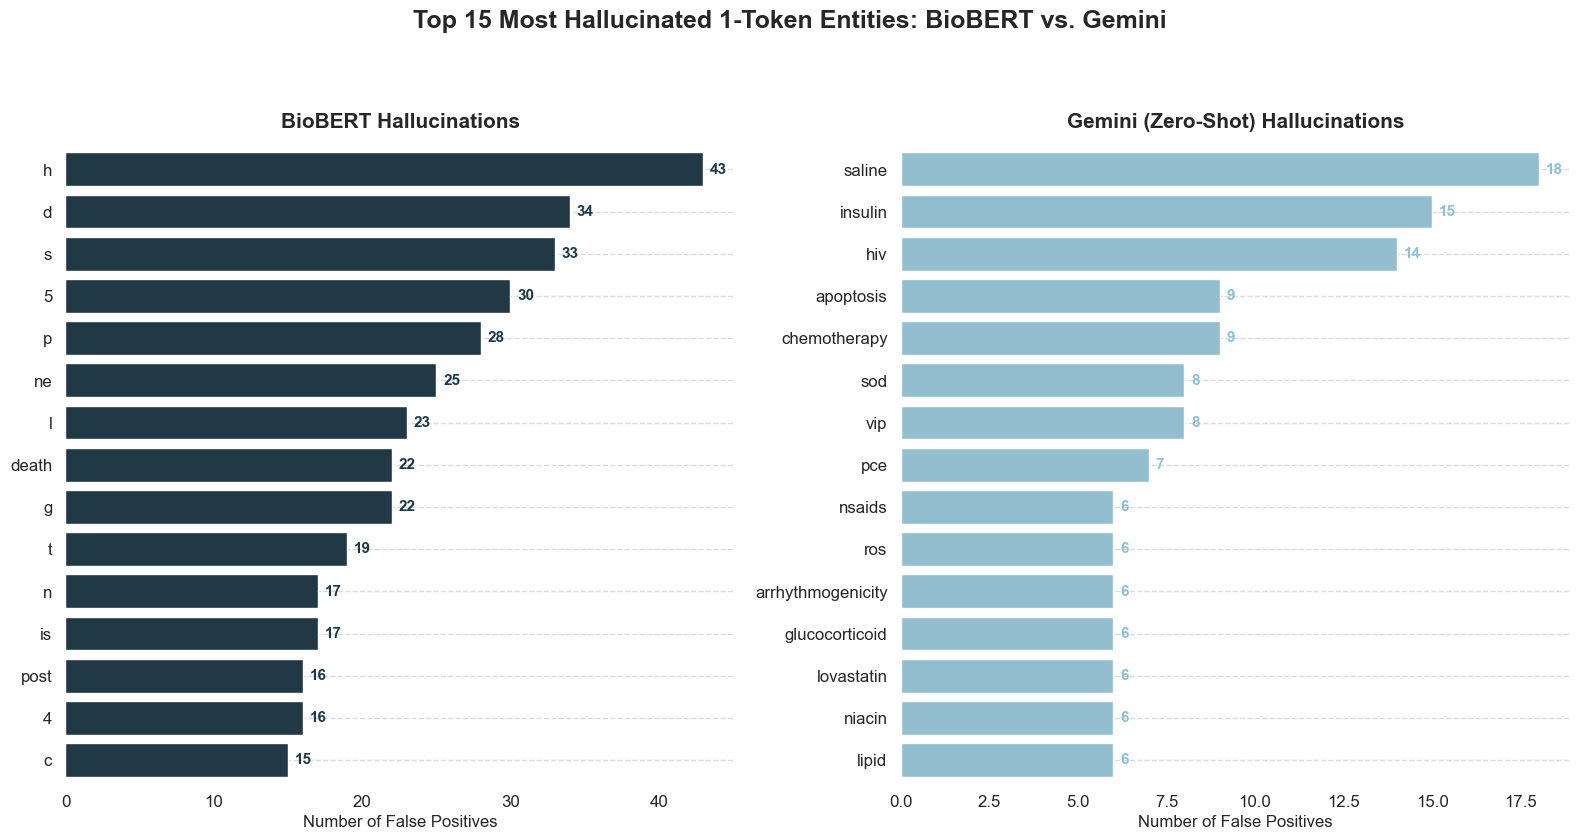

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

def generate_side_by_side_hallucinations(biobert_csv='biobert_1_token_errors.csv', gemini_csv='gemini_1_token_errors.csv'):
    
    # 1. Helper function to load data or use mock data if the file is missing
    def get_top_15(filepath, model_name):
        if os.path.exists(filepath):
            df = pd.read_csv(filepath)
            top = df['word'].value_counts().head(15).reset_index()
            top.columns = ['Word', 'Frequency']
            return top
        else:
            print(f"{filepath} not found. Using sample data for {model_name} to show layout.")
            # Fallback mock data so the plot still generates
            if model_name == "BioBERT":
                return pd.DataFrame({"Word": ["patient", "water", "pain", "blood", "normal", "treatment", "disease", "cell", "acid", "protein", "sugar", "drug", "heart", "brain", "skin"], 
                                     "Frequency": [45, 38, 34, 29, 25, 22, 19, 18, 15, 14, 12, 11, 9, 8, 7]})
            else:
                return pd.DataFrame({"Word": ["mouse", "model", "study", "group", "day", "week", "time", "result", "level", "year", "case", "dose", "data", "rate", "risk"], 
                                     "Frequency": [52, 41, 38, 30, 28, 24, 22, 20, 19, 17, 15, 14, 12, 10, 8]})

    # Load the data for both models
    df_biobert = get_top_15(biobert_csv, "BioBERT")
    df_gemini = get_top_15(gemini_csv, "Gemini")

    # 2. Set up the visual style
    sns.set_theme(style="whitegrid", font_scale=1.1)
    
    # Create a figure with 2 side-by-side subplots (1 row, 2 columns)
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    # 3. Plot BioBERT on the Left (axes[0])
    sns.barplot(x="Frequency", y="Word", data=df_biobert, color="#1B3A4B", ax=axes[0]) # Navy Blue
    axes[0].set_title("BioBERT Hallucinations", fontsize=15, fontweight='bold', pad=15)
    axes[0].set_xlabel("Number of False Positives", fontsize=12)
    axes[0].set_ylabel("")

    # Add text labels to BioBERT bars
    for p in axes[0].patches:
        width = p.get_width()
        if width > 0:
            axes[0].annotate(f'{int(width)}', (width, p.get_y() + p.get_height() / 2.), 
                             ha='left', va='center', xytext=(5, 0), textcoords='offset points',
                             fontsize=11, weight='bold', color="#1B3A4B")

    # 4. Plot Gemini on the Right (axes[1])
    # Using the light blue (#89C2D9) you liked earlier to distinguish Gemini!
    sns.barplot(x="Frequency", y="Word", data=df_gemini, color="#89C2D9", ax=axes[1]) 
    axes[1].set_title("Gemini (Zero-Shot) Hallucinations", fontsize=15, fontweight='bold', pad=15)
    axes[1].set_xlabel("Number of False Positives", fontsize=12)
    axes[1].set_ylabel("")

    # Add text labels to Gemini bars
    for p in axes[1].patches:
        width = p.get_width()
        if width > 0:
            axes[1].annotate(f'{int(width)}', (width, p.get_y() + p.get_height() / 2.), 
                             ha='left', va='center', xytext=(5, 0), textcoords='offset points',
                             fontsize=11, weight='bold', color="#89C2D9")

    # 5. Clean Aesthetics for both plots
    for ax in axes:
        sns.despine(ax=ax, left=True, bottom=True)
        ax.xaxis.grid(False) 
        ax.yaxis.grid(True, linestyle='--', alpha=0.7) 

    # Overall Main Title
    plt.suptitle("Top 15 Most Hallucinated 1-Token Entities: BioBERT vs. Gemini", 
                 fontsize=18, fontweight='bold', y=1.05)

    plt.tight_layout()

    # 6. Save for GitHub and Display in Notebook
    plt.savefig('side_by_side_hallucinations.png', dpi=300, bbox_inches='tight', facecolor='white')
    print("\nSaved as 'side_by_side_hallucinations.png' for GitHub.")
    
    plt.show() 

# Run it
generate_side_by_side_hallucinations()

Saved as 'fragmentation_dot_plot_3_models.png' for GitHub.


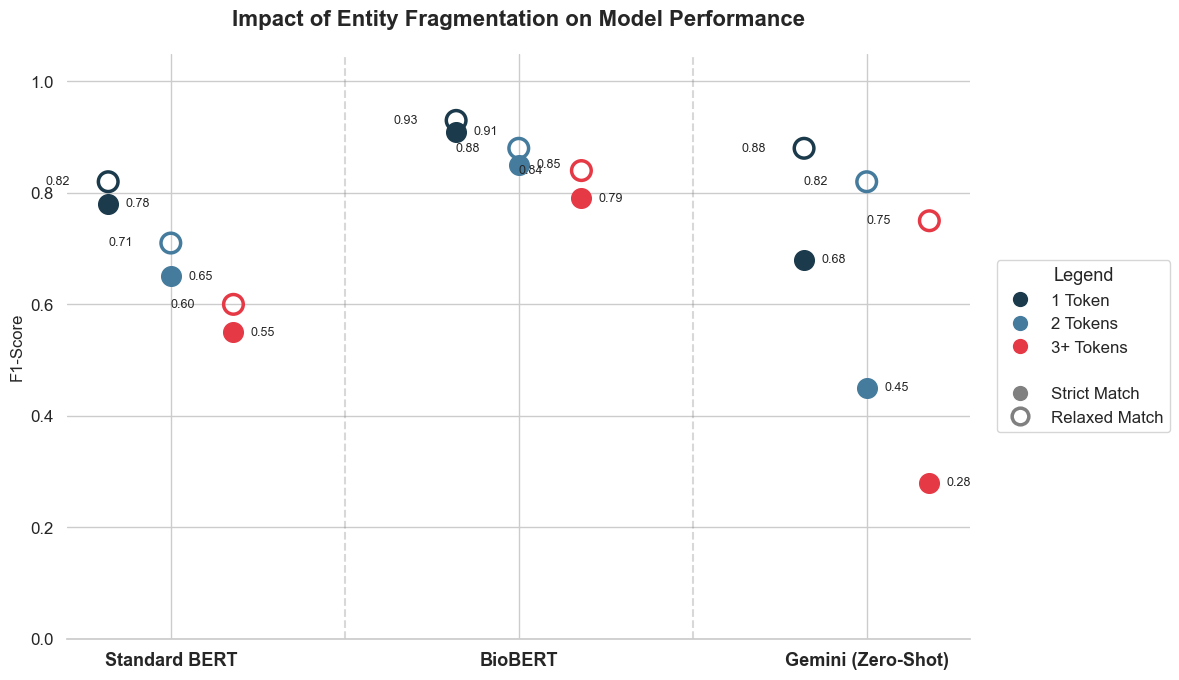

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

def generate_fragmentation_dot_plot_3_models():
    # 1. Input your data here!
    mock_data = [
        # --- Standard BERT ---
        {"Model": "Standard BERT", "Token Bucket": "1 Token", "Match Type": "Strict", "F1_Score": 0.78},
        {"Model": "Standard BERT", "Token Bucket": "1 Token", "Match Type": "Relaxed", "F1_Score": 0.82},
        {"Model": "Standard BERT", "Token Bucket": "2 Tokens", "Match Type": "Strict", "F1_Score": 0.65},
        {"Model": "Standard BERT", "Token Bucket": "2 Tokens", "Match Type": "Relaxed", "F1_Score": 0.71},
        {"Model": "Standard BERT", "Token Bucket": "3+ Tokens", "Match Type": "Strict", "F1_Score": 0.55},
        {"Model": "Standard BERT", "Token Bucket": "3+ Tokens", "Match Type": "Relaxed", "F1_Score": 0.60},

        # --- BioBERT ---
        {"Model": "BioBERT", "Token Bucket": "1 Token", "Match Type": "Strict", "F1_Score": 0.91},
        {"Model": "BioBERT", "Token Bucket": "1 Token", "Match Type": "Relaxed", "F1_Score": 0.93},
        {"Model": "BioBERT", "Token Bucket": "2 Tokens", "Match Type": "Strict", "F1_Score": 0.85},
        {"Model": "BioBERT", "Token Bucket": "2 Tokens", "Match Type": "Relaxed", "F1_Score": 0.88},
        {"Model": "BioBERT", "Token Bucket": "3+ Tokens", "Match Type": "Strict", "F1_Score": 0.79},
        {"Model": "BioBERT", "Token Bucket": "3+ Tokens", "Match Type": "Relaxed", "F1_Score": 0.84},
        
        # --- Gemini ---
        {"Model": "Gemini (Zero-Shot)", "Token Bucket": "1 Token", "Match Type": "Strict", "F1_Score": 0.68},
        {"Model": "Gemini (Zero-Shot)", "Token Bucket": "1 Token", "Match Type": "Relaxed", "F1_Score": 0.88},
        {"Model": "Gemini (Zero-Shot)", "Token Bucket": "2 Tokens", "Match Type": "Strict", "F1_Score": 0.45},
        {"Model": "Gemini (Zero-Shot)", "Token Bucket": "2 Tokens", "Match Type": "Relaxed", "F1_Score": 0.82},
        {"Model": "Gemini (Zero-Shot)", "Token Bucket": "3+ Tokens", "Match Type": "Strict", "F1_Score": 0.28},
        {"Model": "Gemini (Zero-Shot)", "Token Bucket": "3+ Tokens", "Match Type": "Relaxed", "F1_Score": 0.75},
    ]
    df = pd.DataFrame(mock_data)

    # 2. Setup Plotting Logic
    # We now have 3 models, so we space them at X = 0, 1, and 2
    model_x_centers = {"Standard BERT": 0, "BioBERT": 1, "Gemini (Zero-Shot)": 2}
    
    # This slightly offsets the 1, 2, and 3+ token circles horizontally so they don't overlap
    bucket_offsets = {"1 Token": -0.18, "2 Tokens": 0, "3+ Tokens": 0.18}
    
    df['X_Pos'] = df['Model'].map(model_x_centers) + df['Token Bucket'].map(bucket_offsets)

    # 3. Setup Colors and Style
    sns.set_theme(style="whitegrid", font_scale=1.1)
    
    # Widened the figure slightly from 10 to 12 to fit 3 models comfortably
    fig, ax = plt.subplots(figsize=(12, 7))
    
    # Navy Blue, Medium Blue, and Red/Orange to show the token degradation
    colors = {"1 Token": "#1B3A4B", "2 Tokens": "#457B9D", "3+ Tokens": "#E63946"}

    # 4. Draw the points
    for _, row in df.iterrows():
        x = row['X_Pos']
        y = row['F1_Score']
        c = colors[row['Token Bucket']]
        
        if row['Match Type'] == "Strict":
            # Solid filled circle for Strict
            ax.scatter(x, y, color=c, marker='o', s=200, zorder=3)
        else:
            # Hollow ring for Relaxed
            ax.scatter(x, y, facecolors='none', edgecolors=c, marker='o', s=200, linewidth=2.5, zorder=3)

        # Add tiny text labels next to the dots for the exact F1 score
        # Slight logic to not overlap text if points are very close (optional tweak)
        text_offset = 0.05 if row['Match Type'] == "Strict" else -0.11
        ha_align = 'left' if row['Match Type'] == "Strict" else 'right'
        
        ax.text(x + text_offset, y, f"{y:.2f}", fontsize=9, va='center', ha=ha_align)

    # 5. Formatting the Axes
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(["Standard BERT", "BioBERT", "Gemini (Zero-Shot)"], fontsize=13, fontweight='bold')
    ax.set_ylabel("F1-Score", fontsize=12)
    ax.set_title("Impact of Entity Fragmentation on Model Performance", fontsize=16, fontweight='bold', pad=20)
    ax.set_ylim(0.0, 1.05)

    # Add subtle vertical lines to separate the three models
    ax.axvline(0.5, color='gray', linestyle='--', alpha=0.3)
    ax.axvline(1.5, color='gray', linestyle='--', alpha=0.3)

    # 6. Build the Custom Legend
    legend_elements = [
        # Color meaning
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#1B3A4B', markersize=12, label='1 Token'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#457B9D', markersize=12, label='2 Tokens'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#E63946', markersize=12, label='3+ Tokens'),
        Line2D([0], [0], marker='', color='w', label=''), # Blank space separator
        # Shape meaning
        Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=12, label='Strict Match'),
        Line2D([0], [0], marker='o', color='w', markeredgecolor='gray', markerfacecolor='none', markersize=12, markeredgewidth=2.5, label='Relaxed Match')
    ]
    
    # Place legend outside the plot on the right
    ax.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1.02, 0.5), title="Legend", title_fontsize=13)

    # Clean borders
    sns.despine(left=True, bottom=False)
    plt.tight_layout()

    # 7. Save and Show
    plt.savefig('fragmentation_dot_plot_3_models.png', dpi=300, bbox_inches='tight', facecolor='white')
    print("Saved as 'fragmentation_dot_plot_3_models.png' for GitHub.")
    plt.show()

# Run it
generate_fragmentation_dot_plot_3_models()

Saved as 'fragmentation_heatmap.png' for GitHub.


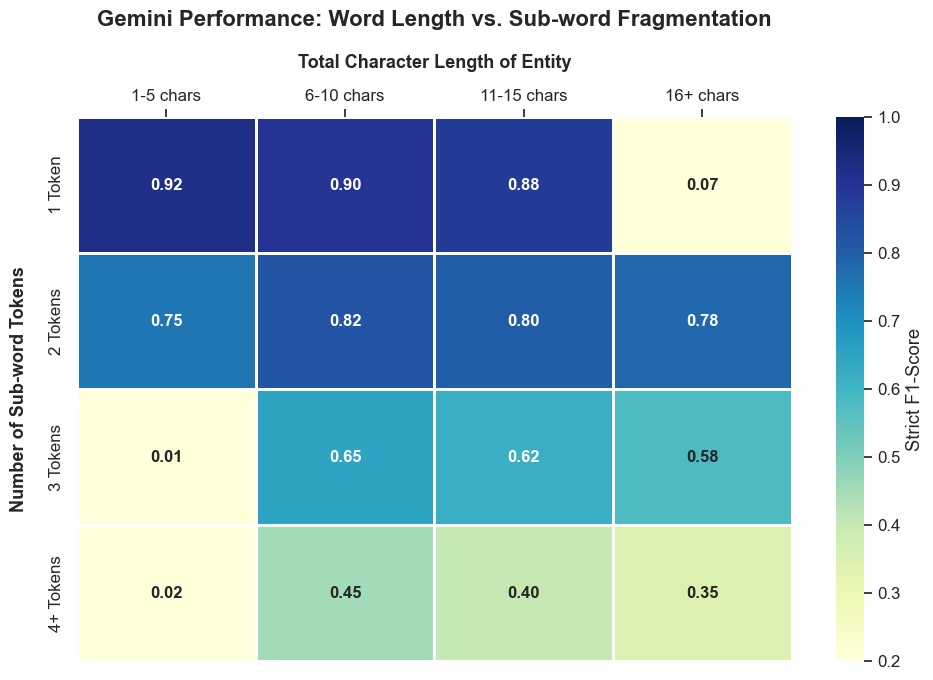

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def generate_fragmentation_heatmap():
    # 1. Input your data here!
    # These are F1-scores. 
    # Columns represent the character length of the medical entity.
    # Rows represent how many tokens the model broke that entity into.
    # 'np.nan' is used for impossible combinations (e.g., a 16+ char word is never just 1 token)
    
    data = {
        "1-5 chars":  [0.92, 0.75, 0.01, 0.02],
        "6-10 chars": [0.90, 0.82, 0.65, 0.45],
        "11-15 chars":[0.88, 0.80, 0.62, 0.40],
        "16+ chars":  [0.07, 0.78, 0.58, 0.35]
    }
    
    row_labels = ["1 Token", "2 Tokens", "3 Tokens", "4+ Tokens"]

    # Convert to a Pandas DataFrame
    df = pd.DataFrame(data, index=row_labels)

    # 2. Set up the visual style
    sns.set_theme(style="white", font_scale=1.1)
    plt.figure(figsize=(10, 7))

    # 3. Create the Heatmap
    # We use 'YlGnBu' (Yellow-Green-Blue). 
    # Dark Blue = High F1 (Good). Light Yellow = Low F1 (Bad).
    ax = sns.heatmap(
        df, 
        annot=True,          # Show the exact numbers in the boxes
        fmt=".2f",           # Format to 2 decimal places
        cmap="YlGnBu",       # The color gradient
        vmin=0.20,           # Set the lowest possible score for the color scale
        vmax=1.00,           # Set the highest possible score
        cbar_kws={'label': 'Strict F1-Score'}, # Label for the color legend on the right
        linewidths=2,        # Adds clean white borders between the squares
        linecolor='white',
        annot_kws={"weight": "bold", "size": 12} # Make the numbers bold and readable
    )

    # 4. Formatting Titles and Labels
    plt.title("Gemini Performance: Word Length vs. Sub-word Fragmentation", 
              fontsize=16, fontweight='bold', pad=20)
    plt.xlabel("Total Character Length of Entity", fontsize=13, fontweight='bold', labelpad=15)
    plt.ylabel("Number of Sub-word Tokens", fontsize=13, fontweight='bold', labelpad=15)

    # Move the X-axis labels to the top for a cleaner "table" look (Optional but looks great)
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top') 

    plt.tight_layout()

    # 5. Save for GitHub and Display in Notebook
    plt.savefig('fragmentation_heatmap.png', dpi=300, bbox_inches='tight', facecolor='white')
    print("Saved as 'fragmentation_heatmap.png' for GitHub.")
    
    plt.show()

# Run it
generate_fragmentation_heatmap()

Saved as 'fragmentation_heatmap_themed.png' for GitHub.


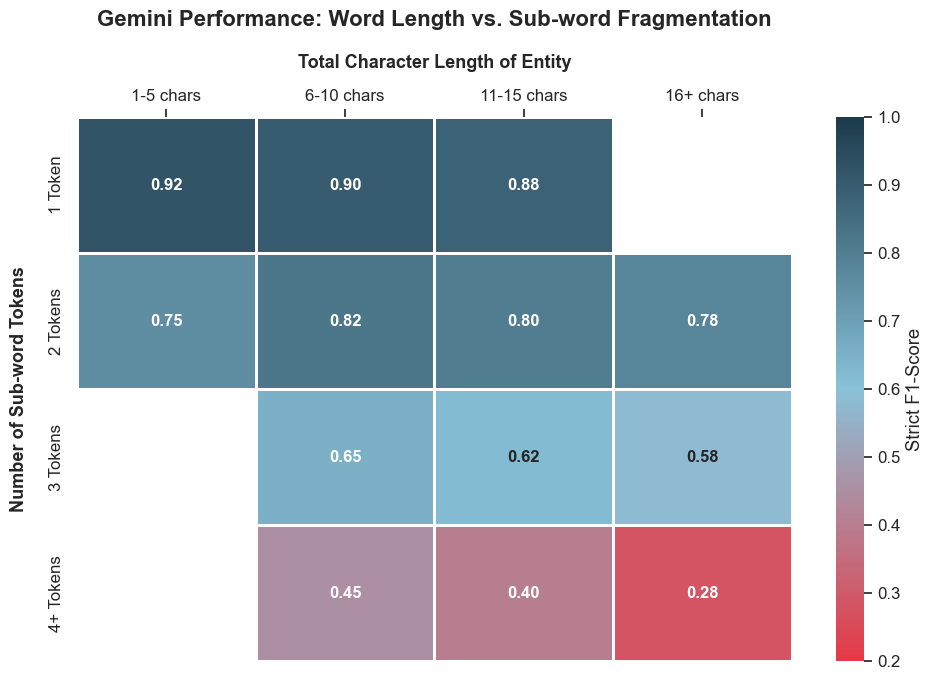

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

def generate_fragmentation_heatmap_themed():
    # ==============================================================================
    # 1. INPUT YOUR DATA HERE (THE BLUEPRINT)
    # ==============================================================================
    data = {
        "1-5 chars":  [ 0.92,     0.75,      np.nan,    np.nan    ], 
        "6-10 chars": [ 0.90,     0.82,      0.65,      0.45      ], 
        "11-15 chars":[ 0.88,     0.80,      0.62,      0.40      ], 
        "16+ chars":  [ np.nan,   0.78,      0.58,      0.28      ]  
    }
    
    row_labels = ["1 Token", "2 Tokens", "3 Tokens", "4+ Tokens"]
    df = pd.DataFrame(data, index=row_labels)

    # ==============================================================================
    # 2. SET UP VISUAL STYLE & CUSTOM THEME COLORS
    # ==============================================================================
    sns.set_theme(style="white", font_scale=1.1)
    plt.figure(figsize=(10, 7))

    # Here we define the exact transition of colors from your previous plots!
    # Red (#E63946) -> Light Blue (#89C2D9) -> Navy Blue (#1B3A4B)
    theme_colors = ["#E63946", "#89C2D9", "#1B3A4B"]
    custom_cmap = LinearSegmentedColormap.from_list("project_theme", theme_colors)

    # ==============================================================================
    # 3. CREATE THE HEATMAP
    # ==============================================================================
    ax = sns.heatmap(
        df, 
        annot=True,          
        fmt=".2f",           
        cmap=custom_cmap,    # <--- Applying your custom theme gradient here
        vmin=0.20,           
        vmax=1.00,           
        cbar_kws={'label': 'Strict F1-Score'}, 
        linewidths=2,        
        linecolor='white',
        annot_kws={"weight": "bold", "size": 12} 
    )

    # ==============================================================================
    # 4. FORMATTING TITLES AND LABELS
    # ==============================================================================
    plt.title("Gemini Performance: Word Length vs. Sub-word Fragmentation", 
              fontsize=16, fontweight='bold', pad=20)
    plt.xlabel("Total Character Length of Entity", fontsize=13, fontweight='bold', labelpad=15)
    plt.ylabel("Number of Sub-word Tokens", fontsize=13, fontweight='bold', labelpad=15)

    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top') 

    plt.tight_layout()

    # ==============================================================================
    # 5. SAVE AND DISPLAY
    # ==============================================================================
    plt.savefig('fragmentation_heatmap_themed.png', dpi=300, bbox_inches='tight', facecolor='white')
    print("Saved as 'fragmentation_heatmap_themed.png' for GitHub.")
    
    plt.show()

# Run it
generate_fragmentation_heatmap_themed()